# Archetype 3 — Base + PV + BSS

## Purpose

Computes the annual TCoE for **Archetype 3: Base + PV + Battery Storage System (10 kWh / 10 kW)** across 3 strategies × 7 DSOs → **21 runs**.

Unlike Archetypes 1–2, strategies differ here because the BSS can shift energy over time:

| Strategy | Schedule | Signal |
|---|---|---|
| **no_flex** | Rule-based PV-priority dispatch (Stute 2024) | none |
| **dt_flex** | Full-horizon MILP, minimise spot cost | spot (ct/kWh) |
| **tcoe_flex** | Full-horizon MILP per DSO, minimise full volumetric marginal | spot + DSO vol + levies |

**Key modelling constraint:** The BSS can only be charged from PV surplus — no grid→BSS charging.

## Input files (`inputs/`)

| File | Content |
|---|---|
| `base_demand_h25_4500kwh_2026_15min.csv` | BDEW H25 demand (kWh/slot) |
| `pv_kassel_10kwp_2026_15min.csv` | 10 kWp PV generation Kassel 2026 (kWh/slot) |
| `spot_prices_de_lu_2025_15min.csv` | Day-ahead spot price (ct/kWh) |
| `bss_parameters_prosumer_10kwh_5kw_2026.csv` | BSS physical parameters |
| `dso_tariffs_residential_2026.csv` | Residential base tariffs for 7 DSOs |
| `residential_taxes_2026.csv` | German levies (ct/kWh, pre-VAT) |

## Output (`outputs/`)

`results_base_pv_bss_2026.csv` — 21 rows × cost-component columns.

## Billing convention

Same as Archetype 2: pre-VAT levy bundle in net subtotal; single 19% VAT on full subtotal. No §14a rebate (PV-only BSS not §14a-eligible in this model). `cost_smart_operating_net_eur = 100 €/year`.

## Solver

Gurobi via PuLP. Requires a valid Gurobi licence. Full-horizon MILP at native 15-min resolution (T = 35,040 binary variables). 

## Thesis reference

Chapter 5, Section 5.1 — Results: Archetype 3 (Base + PV + BSS)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pulp
from pathlib import Path

os.environ['GRB_LICENSE_FILE'] = os.path.expanduser('~/gurobi.lic')

# ── Path configuration ─────────────────────────────────────────────────────────
def find_repo_root(marker='README.md'):
    p = Path('__file__').resolve().parent
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f'Repo root (containing {marker}) not found.')

REPO_ROOT = find_repo_root()
INPUTS    = REPO_ROOT / 'inputs'
OUTPUTS   = REPO_ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print(f'Repo root : {REPO_ROOT}')

Repo root : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub


## Step 1 — Load inputs and BSS parameters

In [2]:
demand_df = pd.read_csv(INPUTS / 'base_demand_h25_4500kwh_2026_15min.csv', parse_dates=['timestamp'])
pv_df     = pd.read_csv(INPUTS / 'pv_kassel_10kwp_2026_15min.csv', parse_dates=['datetime'])
spot_df   = pd.read_csv(INPUTS / 'spot_prices_de_lu_2025_15min.csv', parse_dates=['timestamp'])

pv_df = pv_df.rename(columns={'datetime': 'timestamp'})
df = (demand_df
      .merge(pv_df[['timestamp', 'energy_kWh']], on='timestamp', how='inner')
      .merge(spot_df, on='timestamp', how='inner')
      .rename(columns={'demand_kwh': 'demand_kWh',
                       'energy_kWh': 'pv_kWh',
                       'price_ct_kWh': 'c_spot_ct_kWh'}))

# ── BSS parameters ──────────────────────────────────────────────────────────────
bss_df  = pd.read_csv(INPUTS / 'bss_parameters_prosumer_10kwh_5kw_2026.csv')
bss_df['value_num'] = pd.to_numeric(bss_df['value'], errors='coerce')
bss     = dict(zip(bss_df.dropna(subset=['value_num'])['parameter'],
                   bss_df.dropna(subset=['value_num'])['value_num']))

E_MIN    = float(bss['E_min_kWh'])              # lower SoC bound (kWh)
E_MAX    = float(bss['E_max_kWh'])              # upper SoC bound (kWh)
P_MAX    = float(bss['P_BSS_charge_max_kW'])    # charge = discharge power limit (kW)
ETA_CH   = float(bss['eta_BSS_charge'])
ETA_DIS  = float(bss['eta_BSS_discharge'])
Q_LOSS   = float(bss['q_losses_BSS_per_h'])     # standby self-discharge (1/h)
DT_H     = 0.25                                 # 15-min step = 0.25 h

# ── Tariff data ──────────────────────────────────────────────────────────────────
dso_tariffs = pd.read_csv(INPUTS / 'dso_tariffs_residential_2026.csv')
DSO_LIST    = list(dso_tariffs['DSO'])
taxes       = pd.read_csv(INPUTS / 'residential_taxes_2026.csv')
TAX_PRE_VAT = float(taxes.loc[taxes['region']=='DE', 'Total_no_VAT_ct_kWh'].iloc[0])
VAT_RATE    = 0.19
SMART_OP    = 100.0   # flat net iMSys lump-sum (EUR/year)
ARCHETYPE   = 3
STRATEGIES  = ['no_flex', 'dt_flex', 'tcoe_flex']

# numpy arrays for simulation / MILP
demand_arr = df['demand_kWh'].to_numpy(dtype=float)
pv_arr     = df['pv_kWh'].to_numpy(dtype=float)
spot_arr   = df['c_spot_ct_kWh'].to_numpy(dtype=float)
T          = len(demand_arr)

print(f'Time steps   : {T:,}')
print(f'BSS          : E=[{E_MIN}, {E_MAX}] kWh  P_max={P_MAX} kW  eta_ch={ETA_CH:.4f}  eta_dis={ETA_DIS:.4f}')
print(f'Levies (pre-VAT): {TAX_PRE_VAT} ct/kWh')

Time steps   : 35,040
BSS          : E=[2.0, 9.0] kWh  P_max=10.0 kW  eta_ch=0.9747  eta_dis=0.9747
Levies (pre-VAT): 6.64 ct/kWh


## Step 2 — No-flex schedule (rule-based PV-priority dispatch)

Stute (2024) rule order per timestep:
1. Standby loss applied to current SoC.
2. PV surplus → charge BSS (up to power and headroom limits) → feed remaining to grid.
3. PV deficit → discharge BSS (up to power and available SoC above `E_min`) → import remainder from grid.

In [3]:
E_grid_nf   = np.zeros(T)
E_feedin_nf = np.zeros(T)
soc_nf      = np.full(T + 1, E_MIN)  # SoC trajectory for visualisation

E_BSS = E_MIN  # initialise at minimum buffer

for i in range(T):
    # (1) Standby loss — E_min-anchored: prevents SoC falling below E_min under pure standby
    E_BSS = (1 - Q_LOSS * DT_H) * E_BSS + Q_LOSS * DT_H * E_MIN

    surplus = pv_arr[i] - demand_arr[i]

    if surplus > 1e-9:
        # PV surplus → charge then export
        # take_to_battery: energy taken from PV (before efficiency loss)
        take = min(surplus, P_MAX * DT_H, (E_MAX - E_BSS) / ETA_CH)
        E_BSS = min(E_MAX, E_BSS + ETA_CH * take)
        E_feedin_nf[i] = surplus - take

    elif surplus < -1e-9:
        # PV deficit → discharge then import
        # from_battery: energy delivered to load (after efficiency)
        from_batt = min(-surplus, P_MAX * DT_H, (E_BSS - E_MIN) * ETA_DIS)
        E_BSS = max(E_MIN, E_BSS - from_batt / ETA_DIS)
        E_grid_nf[i] = -surplus - from_batt

    soc_nf[i + 1] = E_BSS

print(f'no_flex  — grid draw: {E_grid_nf.sum():.2f} kWh  |  feed-in: {E_feedin_nf.sum():.2f} kWh')

no_flex  — grid draw: 855.31 kWh  |  feed-in: 8006.18 kWh


## Step 3 — MILP solver (dt_flex / tcoe_flex)

Full-horizon MILP at native 15-min resolution. Decision variables per timestep:
- $E^t_{grid}$, $E^t_{feedin}$ — connection-point flows (kWh)
- PV split: $G^t_{PV→grid}$, $G^t_{PV→load}$, $G^t_{PV→BSS}$ — ensures PV-only charging
- $P^t_{dis}$ — BSS discharge power (kW)
- $E^t_{BSS}$ — SoC trajectory (kWh), $t = 0 \ldots T$
- $z^t_{BSS} \in \{0,1\}$ — charge/discharge exclusivity
- $z^t_m \in \{0,1\}$ — import/export exclusivity

In [4]:
def solve_bss_milp(demand, pv, spot_ct, strategy, c_imp=None,
                   time_limit_s=600):
    """
    Returns (E_grid, E_feedin, soc_trajectory) as numpy arrays.

    strategy : 'dt_flex'   → objective: min sum_t c_spot[t]*(E_grid[t] - E_feedin[t])
               'tcoe_flex' → objective: min sum_t (c_imp[t]*E_grid[t] - c_spot[t]*E_feedin[t])
                             where c_imp[t] = spot + DSO_vol + levies_pre_vat
    """
    n = len(demand)
    prob = pulp.LpProblem('bss', pulp.LpMinimize)

    # ── Variables ──────────────────────────────────────────────────────────────
    E_g    = [pulp.LpVariable(f'Eg_{t}',   lowBound=0) for t in range(n)]
    E_f    = [pulp.LpVariable(f'Ef_{t}',   lowBound=0) for t in range(n)]
    G_grid = [pulp.LpVariable(f'Gg_{t}',   lowBound=0) for t in range(n)]
    G_load = [pulp.LpVariable(f'Gl_{t}',   lowBound=0) for t in range(n)]
    G_bss  = [pulp.LpVariable(f'Gb_{t}',   lowBound=0) for t in range(n)]  # PV→BSS
    P_dis  = [pulp.LpVariable(f'Pd_{t}',   lowBound=0) for t in range(n)]
    E_bss  = [pulp.LpVariable(f'Eb_{t}',   lowBound=E_MIN, upBound=E_MAX)
               for t in range(n + 1)]
    z_bss  = [pulp.LpVariable(f'zb_{t}',   cat='Binary') for t in range(n)]
    z_m    = [pulp.LpVariable(f'zm_{t}',   cat='Binary') for t in range(n)]

    prob += E_bss[0] == E_MIN   # start at lower SoC bound
    M = float(max(demand.max(), 1) + max(pv.max(), 1) + P_MAX * DT_H + 100)  # Big-M for import/export exclusivity; must exceed any feasible flow
    e_ch_max = P_MAX * DT_H  # max energy chargeable per 15-min slot (kWh)

    for t in range(n):
        qt, gt = float(demand[t]), float(pv[t])

        # PV energy balance: all PV goes somewhere
        prob += G_grid[t] + G_load[t] + G_bss[t] == gt
        # Feed-in equals PV sent to grid
        prob += E_f[t] == G_grid[t]
        # Connection-point balance (net import = demand − PV-to-load − BSS discharge)
        prob += E_g[t] - E_f[t] == qt - G_load[t] - G_grid[t] - P_dis[t] * DT_H
        # PV-to-load cannot exceed demand
        prob += G_load[t] <= qt
        # SoC recursion (E_min-anchored standby; PV-only charging)
        prob += E_bss[t+1] == ((1 - Q_LOSS*DT_H)*E_bss[t]
                                + Q_LOSS*DT_H*E_MIN
                                + ETA_CH*G_bss[t]
                                - P_dis[t]*DT_H/ETA_DIS)
        # Power limits
        prob += G_bss[t]  <= e_ch_max
        prob += P_dis[t]  <= P_MAX
        # Charge/discharge exclusivity (z_bss=1 → discharge; z_bss=0 → charge)
        prob += G_bss[t]  <= e_ch_max * (1 - z_bss[t])
        prob += P_dis[t]  <= P_MAX   * z_bss[t]
        # Import/export exclusivity (z_m=1 → import; z_m=0 → export)
        prob += E_g[t]    <= M * z_m[t]
        prob += E_f[t]    <= M * (1 - z_m[t])

    # ── Objective ──────────────────────────────────────────────────────────────
    if strategy == 'dt_flex':
        prob += pulp.lpSum(float(spot_ct[t])*(E_g[t] - E_f[t]) for t in range(n))
    else:  # tcoe_flex
        prob += pulp.lpSum(float(c_imp[t])*E_g[t] - float(spot_ct[t])*E_f[t]
                           for t in range(n))

    solver = pulp.GUROBI(timeLimit=time_limit_s, msg=False)
    prob.solve(solver)

    if prob.status != pulp.LpStatusOptimal:
        print(f'  WARNING: MILP status = {pulp.LpStatus[prob.status]}')

    E_g_arr   = np.array([pulp.value(E_g[t])   or 0.0 for t in range(n)])
    E_f_arr   = np.array([pulp.value(E_f[t])   or 0.0 for t in range(n)])
    soc_arr   = np.array([pulp.value(E_bss[t]) or 0.0 for t in range(n + 1)])
    return E_g_arr, E_f_arr, soc_arr

print('solve_bss_milp defined.')

solve_bss_milp defined.


### Run flex strategies

In [5]:
# ── dt_flex: one MILP call (spot-only objective, same schedule for all 7 DSOs)
print('Running dt_flex MILP...')
E_grid_dt, E_feedin_dt, soc_dt = solve_bss_milp(
    demand_arr, pv_arr, spot_arr, strategy='dt_flex')
print(f'dt_flex  — grid draw: {E_grid_dt.sum():.2f} kWh  |  feed-in: {E_feedin_dt.sum():.2f} kWh')

# ── tcoe_flex: one MILP call per DSO (different c_imp → different schedules)
# Store per-DSO schedules; we reuse them in the billing loop below.
tcoe_schedules = {}
for dso_id in DSO_LIST:
    dso = dso_tariffs.loc[dso_tariffs['DSO'] == dso_id].iloc[0]
    arb = float(dso['Arbeitspreis_ct_kWh'])
    c_imp = spot_arr + arb + TAX_PRE_VAT   # full volumetric import marginal (pre-VAT)
    print(f'Running tcoe_flex MILP for {dso_id}...')
    E_g, E_f, soc = solve_bss_milp(demand_arr, pv_arr, spot_arr,
                                    strategy='tcoe_flex', c_imp=c_imp)
    tcoe_schedules[dso_id] = (E_g, E_f, soc)
    print(f'  grid draw: {E_g.sum():.2f} kWh  |  feed-in: {E_f.sum():.2f} kWh')

Running dt_flex MILP...
Set parameter Username
Set parameter LicenseID to value 2795594
Academic license - for non-commercial use only - expires 2027-03-22
dt_flex  — grid draw: 1577.27 kWh  |  feed-in: 8706.32 kWh
Running tcoe_flex MILP for Westnetz...
  grid draw: 871.27 kWh  |  feed-in: 7994.66 kWh
Running tcoe_flex MILP for Bayernwerk...
  grid draw: 883.90 kWh  |  feed-in: 8006.98 kWh
Running tcoe_flex MILP for E.DIS...
  grid draw: 881.26 kWh  |  feed-in: 8004.36 kWh
Running tcoe_flex MILP for Netze BW...
  grid draw: 877.10 kWh  |  feed-in: 8000.49 kWh
Running tcoe_flex MILP for Stromnetz Berlin...
  grid draw: 877.33 kWh  |  feed-in: 8000.67 kWh
Running tcoe_flex MILP for SH Netz...
  grid draw: 878.72 kWh  |  feed-in: 8001.89 kWh
Running tcoe_flex MILP for MITNETZ STROM...
  grid draw: 879.40 kWh  |  feed-in: 8002.55 kWh


## Step 4 — Compute billing (21 runs)

In [6]:
records = []
run_id  = 0

for strategy in STRATEGIES:
    for dso_id in DSO_LIST:
        run_id += 1
        dso = dso_tariffs.loc[dso_tariffs['DSO'] == dso_id].iloc[0]
        arb     = float(dso['Arbeitspreis_ct_kWh'])
        c_fix   = float(dso['Grundpreis_EUR_year'])

        # Select schedule
        if strategy == 'no_flex':
            E_g, E_f = E_grid_nf, E_feedin_nf
        elif strategy == 'dt_flex':
            E_g, E_f = E_grid_dt, E_feedin_dt
        else:  # tcoe_flex
            E_g, E_f = tcoe_schedules[dso_id][:2]

        annual_grid = E_g.sum()
        c_spot_net  = ((E_g - E_f) * spot_arr).sum() / 100.0   # net spot cost (EUR)
        c_vol       = annual_grid * arb / 100.0
        c_levies    = annual_grid * TAX_PRE_VAT / 100.0

        subtotal = c_spot_net + c_fix + c_vol + SMART_OP + c_levies
        vat      = VAT_RATE * subtotal
        total    = subtotal + vat

        records.append({
            'run_id'                      : run_id,
            'scenario_id'                 : f'{strategy}_{ARCHETYPE}_{dso_id}_2026',
            'strategy'                    : strategy,
            'household_archetype'         : ARCHETYPE,
            'dso_id'                      : dso_id,
            'annual_energy_kWh'           : round(annual_grid, 2),
            'cost_spot_net_eur'           : round(c_spot_net, 2),
            'cost_dso_fixed_net_eur'      : round(c_fix, 2),
            'cost_dso_volumetric_net_eur' : round(c_vol, 2),
            'cost_smart_operating_net_eur': round(SMART_OP, 2),
            'cost_levies_pre_vat_eur'     : round(c_levies, 2),
            'subtotal_net_eur'            : round(subtotal, 2),
            'vat_eur'                     : round(vat, 2),
            'total_tcoe_eur'              : round(total, 2),
        })

results = pd.DataFrame(records)
results

,run_id,scenario_id,strategy,household_archetype,dso_id,annual_energy_kWh,cost_spot_net_eur,cost_dso_fixed_net_eur,cost_dso_volumetric_net_eur,cost_smart_operating_net_eur,cost_levies_pre_vat_eur,subtotal_net_eur,vat_eur,total_tcoe_eur
0,1,no_flex_3_Westnetz_2026,no_flex,3,Westnetz,855.31,-285.98,80.30,81.51,100.0,56.79,32.62,6.20,38.82
1,2,no_flex_3_Bayernwerk_2026,no_flex,3,Bayernwerk,855.31,-285.98,98.55,40.37,100.0,56.79,9.73,1.85,11.58
2,3,no_flex_3_E.DIS_2026,no_flex,3,E.DIS,855.31,-285.98,76.65,46.79,100.0,56.79,-5.75,-1.09,-6.84
3,4,no_flex_3_Netze BW_2026,no_flex,3,Netze BW,855.31,-285.98,84.00,64.75,100.0,56.79,19.56,3.72,23.28
4,5,no_flex_3_Stromnetz Berlin_2026,no_flex,3,Stromnetz Berlin,855.31,-285.98,33.36,63.81,100.0,56.79,-32.02,-6.08,-38.11
5,6,no_flex_3_SH Netz_2026,no_flex,3,SH Netz,855.31,-285.98,94.90,54.74,100.0,56.79,20.45,3.89,24.34
6,7,no_flex_3_MITNETZ STROM_2026,no_flex,3,MITNETZ STROM,855.31,-285.98,73.00,53.97,100.0,56.79,-2.22,-0.42,-2.64
7,8,dt_flex_3_Westnetz_2026,dt_flex,3,Westnetz,1577.27,-452.37,80.30,150.31,100.0,104.73,-17.03,-3.24,-20.26
8,9,dt_flex_3_Bayernwerk_2026,dt_flex,3,Bayernwerk,1577.27,-452.37,98.55,74.45,100.0,104.73,-74.65,-14.18,-88.83
9,10,dt_flex_3_E.DIS_2026,dt_flex,3,E.DIS,1577.27,-452.37,76.65,86.28,100.0,104.73,-84.72,-16.10,-100.81


## Step 5 — QA checks

In [8]:
# Energy balance: for each slot, grid - feedin = demand - pv (net of BSS)
# Grid draw must be non-negative
assert (E_grid_nf >= -1e-6).all(),  'no_flex: negative grid draw'
assert (E_feedin_nf >= -1e-6).all(),'no_flex: negative feed-in'
assert (E_grid_dt >= -1e-6).all(),  'dt_flex: negative grid draw'

# Annual grid draw must be < site consumption (PV reduces imports)
site_kwh = demand_arr.sum()
assert E_grid_nf.sum() < site_kwh, 'no_flex: grid draw ≥ site consumption'
assert E_grid_dt.sum() < site_kwh, 'dt_flex: grid draw ≥ site consumption'

# dt_flex must not be worse than no_flex on spot cost (it minimises spot cost)
spot_nf = ((E_grid_nf - E_feedin_nf) * spot_arr).sum()
spot_dt = ((E_grid_dt - E_feedin_dt) * spot_arr).sum()
assert spot_dt <= spot_nf + 1e-3, f'dt_flex spot cost ({spot_dt:.2f}) > no_flex ({spot_nf:.2f})'

# Result table: 21 rows, TCoE values positive
assert len(results) == 21
assert results['total_tcoe_eur'].notna().all(), 'NaN in TCoE results'
# Note: negative TCoE is valid for Base+PV+BSS — PV feed-in revenue can exceed total costs

print('All QA checks passed.')
print(f'no_flex  grid draw : {E_grid_nf.sum():.2f} kWh')
print(f'dt_flex  grid draw : {E_grid_dt.sum():.2f} kWh')
print(f'Spot cost no_flex  : {spot_nf/100:.2f} EUR (ct total / 100)')
print(f'Spot cost dt_flex  : {spot_dt/100:.2f} EUR')
print(f'TCoE range         : {results["total_tcoe_eur"].min()} – {results["total_tcoe_eur"].max()} EUR/year')

All QA checks passed.
no_flex  grid draw : 855.31 kWh
dt_flex  grid draw : 1577.27 kWh
Spot cost no_flex  : -285.98 EUR (ct total / 100)
Spot cost dt_flex  : -452.37 EUR
TCoE range         : -214.75 – 38.82 EUR/year


## Step 6 — SoC visualisation: how price signals drive different BSS charging

Two representative weeks (winter and summer) for one DSO (Westnetz, highest §14a Module 3 spread) showing how the three strategies differ in SoC trajectory and PV utilisation.

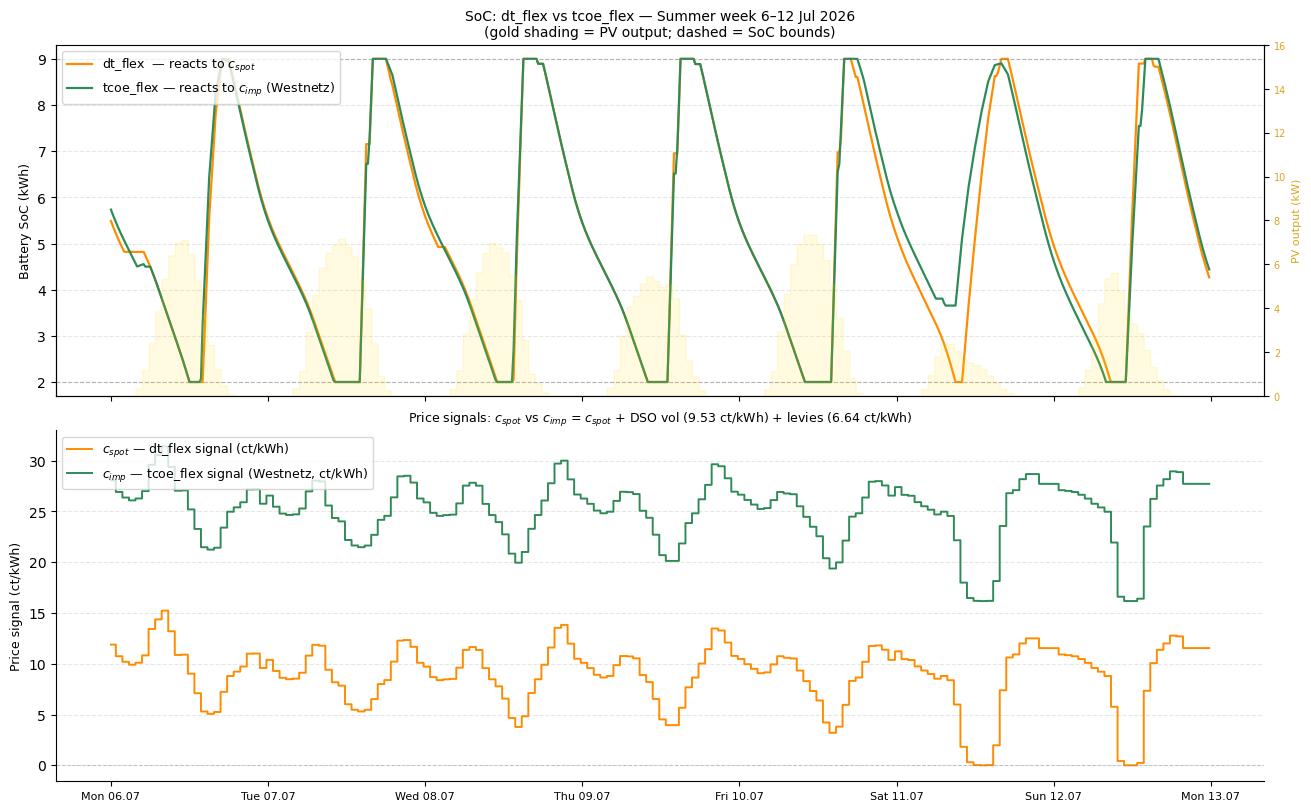

In [15]:
# Representative DSO for tcoe_flex price signal: Westnetz (highest §14a Module 3 spread)
REF_DSO     = 'Westnetz'
dso_ref     = dso_tariffs.loc[dso_tariffs['DSO'] == REF_DSO].iloc[0]
arb_ref     = float(dso_ref['Arbeitspreis_ct_kWh'])
c_imp_ref   = spot_arr + arb_ref + TAX_PRE_VAT   # full volumetric import marginal (pre-VAT, ct/kWh)

soc_tc_wn = tcoe_schedules[REF_DSO][2]   # SoC trajectory for tcoe_flex@Westnetz
ts        = df['timestamp'].values

# Summer week: high PV → strategies diverge most clearly
sum_mask  = ((df['timestamp'] >= '2026-07-06') &
             (df['timestamp'] <  '2026-07-13')).values
t_idx     = np.where(sum_mask)[0]
x         = pd.to_datetime(ts[sum_mask])

fig, (ax_soc, ax_price) = plt.subplots(2, 1, figsize=(13, 8),
                                         constrained_layout=True, sharex=True)

# ── Top: SoC comparison + PV background ────────────────────────────────────────
ax_pv = ax_soc.twinx()
ax_pv.fill_between(x, 0, pv_arr[sum_mask] * 4,   # kWh/slot → kW
                   alpha=0.12, color='gold', step='pre')
ax_pv.set_ylabel('PV output (kW)', color='goldenrod', fontsize=8)
ax_pv.tick_params(axis='y', labelcolor='goldenrod', labelsize=7)
ax_pv.set_ylim(0, 16)

ax_soc.plot(x, soc_dt[t_idx],    lw=1.6, color='darkorange',
            label='dt_flex  — reacts to $c_{spot}$')
ax_soc.plot(x, soc_tc_wn[t_idx], lw=1.6, color='seagreen',
            label=f'tcoe_flex — reacts to $c_{{imp}}$ ({REF_DSO})')
ax_soc.axhline(E_MIN, color='grey', lw=0.8, ls='--', alpha=0.5)
ax_soc.axhline(E_MAX, color='grey', lw=0.8, ls='--', alpha=0.5)
ax_soc.set_ylabel('Battery SoC (kWh)', fontsize=9)
ax_soc.set_ylim(E_MIN - 0.3, E_MAX + 0.3)
ax_soc.set_title('SoC: dt_flex vs tcoe_flex — Summer week 6–12 Jul 2026\n'
                 '(gold shading = PV output; dashed = SoC bounds)', fontsize=10)
ax_soc.legend(loc='upper left', fontsize=9)
ax_soc.grid(axis='y', linestyle='--', alpha=0.3)
ax_soc.spines[['top']].set_visible(False)

# ── Bottom: price signals ────────────────────────────────────────────────────────
ax_price.step(x, spot_arr[sum_mask],  where='pre', lw=1.4,
              color='darkorange', label='$c_{spot}$ — dt_flex signal (ct/kWh)')
ax_price.step(x, c_imp_ref[sum_mask], where='pre', lw=1.4,
              color='seagreen',   label=f'$c_{{imp}}$ — tcoe_flex signal ({REF_DSO}, ct/kWh)')
ax_price.axhline(0, color='grey', lw=0.7, ls='--', alpha=0.4)
ax_price.set_ylabel('Price signal (ct/kWh)', fontsize=9)
ax_price.set_title(f'Price signals: $c_{{spot}}$ vs $c_{{imp}}$ = $c_{{spot}}$ + DSO vol ({arb_ref} ct/kWh) + levies ({TAX_PRE_VAT} ct/kWh)',
                   fontsize=9)
ax_price.legend(loc='upper left', fontsize=9)
ax_price.grid(axis='y', linestyle='--', alpha=0.3)
ax_price.spines[['top', 'right']].set_visible(False)
ax_price.xaxis.set_major_formatter(mdates.DateFormatter('%a %d.%m'))
ax_price.xaxis.set_major_locator(mdates.DayLocator())
ax_price.tick_params(axis='x', labelsize=8)

plt.show()


## Step 7 — Results summary and export

In [16]:
# ── Table 1: no_flex cost breakdown (reference — comparable to Archetypes 1 & 2) ────
nf = (results[results['strategy'] == 'no_flex']
      [['dso_id', 'cost_spot_net_eur', 'cost_dso_fixed_net_eur',
        'cost_dso_volumetric_net_eur', 'cost_levies_pre_vat_eur',
        'cost_smart_operating_net_eur', 'vat_eur', 'total_tcoe_eur']]
      .set_index('dso_id')
      .rename(columns={
          'cost_spot_net_eur'              : 'Spot net (€)',
          'cost_dso_fixed_net_eur'          : 'DSO fix (€)',
          'cost_dso_volumetric_net_eur'     : 'DSO vol (€)',
          'cost_levies_pre_vat_eur'         : 'Levies pre-VAT (€)',
          'cost_smart_operating_net_eur'    : 'Smart op. (€)',
          'vat_eur'                         : 'VAT (€)',
          'total_tcoe_eur'                  : 'TCoE no_flex (€/yr)',
      }))

print(f'Annual grid draw (no_flex): {E_grid_nf.sum():.2f} kWh  |  feed-in: {E_feedin_nf.sum():.2f} kWh')
print(f'TCoE range (all 21 runs)  : {results["total_tcoe_eur"].min():.2f} – {results["total_tcoe_eur"].max():.2f} EUR/year\n')
print('Table 1 — no_flex cost breakdown (reference):')
display(nf)

# ── Table 2: strategy comparison — TCoE and flex savings per DSO ─────────────────
piv = results.pivot_table(index='dso_id', columns='strategy',
                           values='total_tcoe_eur', aggfunc='first')
piv = piv[['no_flex', 'dt_flex', 'tcoe_flex']]   # fixed column order
piv.columns.name = None
piv['saving dt_flex (€/yr)']   = piv['no_flex'] - piv['dt_flex']
piv['saving tcoe_flex (€/yr)'] = piv['no_flex'] - piv['tcoe_flex']
piv = piv.rename(columns={
    'no_flex'   : 'TCoE no_flex (€/yr)',
    'dt_flex'   : 'TCoE dt_flex (€/yr)',
    'tcoe_flex' : 'TCoE tcoe_flex (€/yr)',
})
print('\nTable 2 — strategy comparison and flex savings vs no_flex:')
display(piv)

out = OUTPUTS / 'results_base_pv_bss_2026.csv'
results.to_csv(out, index=False)
print(f'\nSaved : {out}')
print(f'Rows  : {len(results)}  (3 strategies × 7 DSOs)')


Annual grid draw (no_flex): 855.31 kWh  |  feed-in: 8006.18 kWh
TCoE range (all 21 runs)  : -214.75 – 38.82 EUR/year

Table 1 — no_flex cost breakdown (reference):


,Spot net (€),DSO fix (€),DSO vol (€),Levies pre-VAT (€),Smart op. (€),VAT (€),TCoE no_flex (€/yr)
dso_id,,,,,,,
Westnetz,-285.98,80.30,81.51,56.79,100.0,6.20,38.82
Bayernwerk,-285.98,98.55,40.37,56.79,100.0,1.85,11.58
E.DIS,-285.98,76.65,46.79,56.79,100.0,-1.09,-6.84
Netze BW,-285.98,84.00,64.75,56.79,100.0,3.72,23.28
Stromnetz Berlin,-285.98,33.36,63.81,56.79,100.0,-6.08,-38.11
SH Netz,-285.98,94.90,54.74,56.79,100.0,3.89,24.34
MITNETZ STROM,-285.98,73.00,53.97,56.79,100.0,-0.42,-2.64



Table 2 — strategy comparison and flex savings vs no_flex:


,TCoE no_flex (€/yr),TCoE dt_flex (€/yr),TCoE tcoe_flex (€/yr),saving dt_flex (€/yr),saving tcoe_flex (€/yr)
dso_id,,,,,
Bayernwerk,11.58,-88.83,-165.86,100.41,177.44
E.DIS,-6.84,-100.81,-184.05,93.97,177.21
MITNETZ STROM,-2.64,-89.39,-179.59,86.75,176.95
Netze BW,23.28,-52.65,-153.34,75.93,176.62
SH Netz,24.34,-61.64,-152.59,85.98,176.93
Stromnetz Berlin,-38.11,-114.98,-214.75,76.87,176.64
Westnetz,38.82,-20.26,-137.36,59.08,176.18



Saved : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/outputs/results_base_pv_bss_2026.csv
Rows  : 21  (3 strategies × 7 DSOs)
